In [1]:
!pip -q install numpy pandas matplotlib tqdm

In [2]:
import json
import math
import re
import shutil
import zipfile
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [3]:
ROOT = Path("/content/exointel_final_merge")
UPLOAD_DIR = ROOT / "uploaded_zips"
EXTRACT_DIR = ROOT / "extracted"
FINAL_DIR = ROOT / "final_package"
DATA_DIR = FINAL_DIR / "data"
LC_DIR = DATA_DIR / "lightcurves"
BACKUP_DIR = DATA_DIR / "lightcurves_raw_backup"

for d in [UPLOAD_DIR, EXTRACT_DIR, DATA_DIR, LC_DIR, BACKUP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("UPLOAD_DIR:", UPLOAD_DIR)
print("FINAL data folder:", DATA_DIR)

ROOT: /content/exointel_final_merge
UPLOAD_DIR: /content/exointel_final_merge/uploaded_zips
FINAL data folder: /content/exointel_final_merge/final_package/data


In [5]:
from google.colab import files

uploaded = files.upload()

for name, content in uploaded.items():
    path = UPLOAD_DIR / name
    path.write_bytes(content)
    print("Uploaded:", path, "size:", round(path.stat().st_size / 1024 / 1024, 2), "MB")

Saving exointel_real_data_package (1).zip to exointel_real_data_package (1).zip
Saving exointel_real_data_package.zip to exointel_real_data_package.zip
Uploaded: /content/exointel_final_merge/uploaded_zips/exointel_real_data_package (1).zip size: 3.14 MB
Uploaded: /content/exointel_final_merge/uploaded_zips/exointel_real_data_package.zip size: 0.58 MB


In [6]:
zip_paths = sorted(UPLOAD_DIR.glob("*.zip"))

print("ZIP files found:", len(zip_paths))
for z in zip_paths:
    print(" -", z.name)

for idx, zip_path in enumerate(zip_paths, start=1):
    out_dir = EXTRACT_DIR / f"zip_{idx}_{zip_path.stem.replace(' ', '_')}"
    out_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)

    print("\nExtracted:", zip_path.name)
    print("To:", out_dir)

    exoplanet_files = list(out_dir.rglob("exoplanets.json"))
    lc_files = list(out_dir.rglob("lightcurves/*.json"))

    print("  exoplanets.json files:", len(exoplanet_files))
    print("  lightcurve JSON files:", len(lc_files))

    if exoplanet_files:
        try:
            cat = json.loads(exoplanet_files[0].read_text())
            targets = cat.get("targets", [])
            real_count = sum(1 for t in targets if t.get("lightcurve_available"))
            print("  target_count:", cat.get("target_count"), "| targets:", len(targets), "| real LC flags:", real_count)
        except Exception as exc:
            print("  Could not read catalog:", exc)

ZIP files found: 2
 - exointel_real_data_package (1).zip
 - exointel_real_data_package.zip

Extracted: exointel_real_data_package (1).zip
To: /content/exointel_final_merge/extracted/zip_1_exointel_real_data_package_(1)
  exoplanets.json files: 1
  lightcurve JSON files: 174
  target_count: 200 | targets: 200 | real LC flags: 174

Extracted: exointel_real_data_package.zip
To: /content/exointel_final_merge/extracted/zip_2_exointel_real_data_package
  exoplanets.json files: 1
  lightcurve JSON files: 25
  target_count: 200 | targets: 200 | real LC flags: 25


In [7]:
def slugify(value):
    text = str(value or "unknown-target").strip().lower()
    text = text.replace("+", " plus ")
    text = re.sub(r"[’'\"]", "", text)
    text = re.sub(r"[^a-z0-9]+", "-", text)
    text = re.sub(r"^-+|-+$", "", text)
    return text or "unknown-target"


def target_key(t):
    return (
        str(t.get("pl_name", "")).strip().lower(),
        str(t.get("hostname", "")).strip().lower(),
    )


def load_json_safe(path):
    try:
        return json.loads(Path(path).read_text(encoding="utf-8"))
    except Exception:
        return None


def count_lc_points(path):
    payload = load_json_safe(path)
    if not isinstance(payload, dict):
        return 0

    if isinstance(payload.get("points"), list):
        return len(payload["points"])

    if isinstance(payload.get("phase"), list) and isinstance(payload.get("flux"), list):
        return min(len(payload["phase"]), len(payload["flux"]))

    return 0


# Merge target catalogs
merged_targets = {}
catalog_sources = []

for catalog_path in EXTRACT_DIR.rglob("exoplanets.json"):
    payload = load_json_safe(catalog_path)

    if not isinstance(payload, dict):
        continue

    targets = payload.get("targets", [])
    if not isinstance(targets, list):
        continue

    catalog_sources.append(str(catalog_path))

    for t in targets:
        if not isinstance(t, dict):
            continue

        key = target_key(t)
        if not key[0] or not key[1]:
            continue

        existing = merged_targets.get(key)

        if existing is None:
            merged_targets[key] = dict(t)
        else:
            # Merge fields, prefer non-empty values and preserve lightcurve_available True
            merged = dict(existing)
            for k, v in t.items():
                if v is not None and v != "":
                    merged[k] = v
            merged["lightcurve_available"] = bool(existing.get("lightcurve_available")) or bool(t.get("lightcurve_available"))
            merged_targets[key] = merged

print("Catalog sources used:", len(catalog_sources))
for s in catalog_sources:
    print(" -", s)

print("Merged targets:", len(merged_targets))


# Merge lightcurve files
copied = 0
duplicates = 0
skipped_nondata = 0

all_lc_files = sorted(EXTRACT_DIR.rglob("lightcurves/*.json"))

for src in all_lc_files:
    dst = LC_DIR / src.name

    if not dst.exists():
        shutil.copy2(src, dst)
        copied += 1
    else:
        duplicates += 1
        # Keep the file with more points, because it usually contains more usable data before cleaning
        old_points = count_lc_points(dst)
        new_points = count_lc_points(src)

        if new_points > old_points:
            shutil.copy2(src, dst)

print("Lightcurve files found:", len(all_lc_files))
print("Copied unique lightcurves:", len(list(LC_DIR.glob('*.json'))))
print("Duplicate filenames handled:", duplicates)

Catalog sources used: 2
 - /content/exointel_final_merge/extracted/zip_2_exointel_real_data_package/data/exoplanets.json
 - /content/exointel_final_merge/extracted/zip_1_exointel_real_data_package_(1)/data/exoplanets.json
Merged targets: 200
Lightcurve files found: 199
Copied unique lightcurves: 174
Duplicate filenames handled: 25


In [8]:
targets = list(merged_targets.values())

# Ensure every target has lightcurve_file
for t in targets:
    if not t.get("lightcurve_file"):
        t["lightcurve_file"] = f"{slugify(t.get('pl_name'))}.json"

# Mark availability based on actual file presence
available_files = {p.name for p in LC_DIR.glob("*.json")}

for t in targets:
    t["lightcurve_available"] = t.get("lightcurve_file") in available_files

# Sort: real LC first, then transit depth
def sort_score(t):
    real = 1 if t.get("lightcurve_available") else 0
    depth = t.get("pl_trandep") or 0
    try:
        depth = float(depth)
    except Exception:
        depth = 0
    return (-real, -depth, str(t.get("pl_name", "")))

targets = sorted(targets, key=sort_score)

cache = {
    "schema": "exointel-prime-final-merged-cache-v1",
    "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "source": "Merged Colab package from NASA Exoplanet Archive target cache and local MAST lightcurve JSON files",
    "target_count": len(targets),
    "lightcurve_count": len(available_files),
    "lightcurve_directory": "data/lightcurves",
    "columns": list(targets[0].keys()) if targets else [],
    "targets": targets,
}

EXOPLANET_JSON = DATA_DIR / "exoplanets.json"
EXOPLANET_JSON.write_text(json.dumps(cache, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

print("Final merged target count:", len(targets))
print("Final merged lightcurve files:", len(available_files))
print("Saved:", EXOPLANET_JSON)

print("\nFirst 10 real-LC targets:")
for t in [x for x in targets if x.get("lightcurve_available")][:10]:
    print(" ", t["pl_name"], "|", t["lightcurve_file"])

Final merged target count: 200
Final merged lightcurve files: 174
Saved: /content/exointel_final_merge/final_package/data/exoplanets.json

First 10 real-LC targets:
  WTS-2 b | wts-2-b.json
  HATS-6 b | hats-6-b.json
  Kepler-45 b | kepler-45-b.json
  CoRoT-18 b | corot-18-b.json
  WASP-43 b | wasp-43-b.json
  HD 189733 b | hd-189733-b.json
  Kepler-428 b | kepler-428-b.json
  Kepler-17 b | kepler-17-b.json
  HAT-P-18 b | hat-p-18-b.json
  HAT-P-37 b | hat-p-37-b.json


In [9]:
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

for p in LC_DIR.glob("*.json"):
    backup_path = BACKUP_DIR / p.name
    if not backup_path.exists():
        shutil.copy2(p, backup_path)

print("Raw lightcurves:", len(list(LC_DIR.glob('*.json'))))
print("Backup lightcurves:", len(list(BACKUP_DIR.glob('*.json'))))

Raw lightcurves: 174
Backup lightcurves: 174


In [11]:
target_by_file = {t.get("lightcurve_file"): t for t in targets if t.get("lightcurve_file")}


def load_phase_flux(path):
    payload = json.loads(Path(path).read_text(encoding="utf-8"))

    if isinstance(payload.get("points"), list):
        phase = np.array([p.get("phase", np.nan) for p in payload["points"]], dtype=float)
        flux = np.array([p.get("flux", np.nan) for p in payload["points"]], dtype=float)
    else:
        phase = np.array(payload.get("phase", []), dtype=float)
        flux = np.array(payload.get("flux", []), dtype=float)

    mask = np.isfinite(phase) & np.isfinite(flux)
    phase = phase[mask]
    flux = flux[mask]

    # Keep phase in a sensible range
    phase = ((phase + 0.5) % 1.0) - 0.5

    order = np.argsort(phase)
    return phase[order], flux[order], payload


def robust_sigma(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 5:
        return np.nan

    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))

    if not np.isfinite(mad) or mad <= 0:
        return np.nan

    return 1.4826 * mad


def estimate_duration_phase(target):
    period = target.get("pl_orbper")
    duration_h = target.get("pl_trandur")

    try:
        period = float(period)
        duration_h = float(duration_h)
    except Exception:
        return 0.018

    if not np.isfinite(period) or not np.isfinite(duration_h) or period <= 0 or duration_h <= 0:
        return 0.018

    return float(duration_h / 24.0 / period)


def estimate_crop_window(target):
    duration_phase = estimate_duration_phase(target)

    # Several transit durations around phase zero, but do not keep huge windows
    window = 5.0 * duration_phase

    return float(np.clip(window, 0.018, 0.075))


def expected_depth_fraction(target):
    depth_ppm = target.get("pl_trandep")

    try:
        depth_ppm = float(depth_ppm)
    except Exception:
        depth_ppm = np.nan

    if np.isfinite(depth_ppm) and depth_ppm > 0:
        return depth_ppm / 1e6

    rp_rs = target.get("pl_ratror")

    try:
        rp_rs = float(rp_rs)
    except Exception:
        rp_rs = np.nan

    if np.isfinite(rp_rs) and rp_rs > 0:
        return rp_rs * rp_rs

    return 0.01


def median_bin(phase, flux, max_points=1200):
    phase = np.asarray(phase, dtype=float)
    flux = np.asarray(flux, dtype=float)

    mask = np.isfinite(phase) & np.isfinite(flux)
    phase = phase[mask]
    flux = flux[mask]

    if len(phase) <= max_points:
        order = np.argsort(phase)
        return phase[order], flux[order]

    edges = np.linspace(np.nanmin(phase), np.nanmax(phase), max_points + 1)
    b_phase = []
    b_flux = []

    for i in range(max_points):
        m = (phase >= edges[i]) & (phase < edges[i + 1])
        if m.sum() == 0:
            continue
        b_phase.append(np.nanmedian(phase[m]))
        b_flux.append(np.nanmedian(flux[m]))

    return np.array(b_phase), np.array(b_flux)


def recentre_small_phase_offset(phase, flux, target):
    phase = np.asarray(phase, dtype=float)
    flux = np.asarray(flux, dtype=float)

    if len(phase) < 80:
        return phase, flux, 0.0

    duration_phase = estimate_duration_phase(target)
    max_shift = min(0.035, max(0.012, 3.0 * duration_phase))

    n_low = max(8, len(flux) // 40)
    idx = np.argsort(flux)[:n_low]
    centre = np.nanmedian(phase[idx])

    if np.isfinite(centre) and abs(centre) <= max_shift:
        shifted = ((phase - centre + 0.5) % 1.0) - 0.5
        order = np.argsort(shifted)
        return shifted[order], flux[order], float(centre)

    return phase, flux, 0.0


def clean_phase_lightcurve(phase, flux, target):
    phase = np.asarray(phase, dtype=float)
    flux = np.asarray(flux, dtype=float)

    mask = np.isfinite(phase) & np.isfinite(flux) & (flux > 0.2) & (flux < 1.8)
    phase = phase[mask]
    flux = flux[mask]

    if len(phase) < 40:
        return phase, flux, {"status": "too_few_initial"}

    # Initial robust normalisation
    med = np.nanmedian(flux)
    if np.isfinite(med) and med > 0:
        flux = flux / med

    duration_phase = estimate_duration_phase(target)
    crop_window = estimate_crop_window(target)
    transit_half_width = max(0.007, 1.7 * duration_phase)
    depth = expected_depth_fraction(target)

    # Out-of-transit baseline mask
    oot = np.abs(phase) > transit_half_width

    # Robustly remove huge outliers from the baseline fit
    if oot.sum() >= 25:
        oot_flux = flux[oot]
        oot_med = np.nanmedian(oot_flux)
        oot_sig = robust_sigma(oot_flux)

        if np.isfinite(oot_sig) and oot_sig > 0:
            baseline_keep = np.abs(oot_flux - oot_med) < max(0.08, 6.0 * oot_sig)
            xfit = phase[oot][baseline_keep]
            yfit = flux[oot][baseline_keep]
        else:
            xfit = phase[oot]
            yfit = flux[oot]

        if len(xfit) >= 25:
            try:
                span = np.nanmax(phase) - np.nanmin(phase)
                degree = 2 if span > 0.07 else 1
                coeff = np.polyfit(xfit, yfit, deg=degree)
                trend = np.polyval(coeff, phase)

                good_trend = np.isfinite(trend) & (trend > 0.25) & (trend < 2.5)

                if good_trend.sum() > 0.8 * len(trend):
                    flux = flux / trend
            except Exception:
                pass

    # Re-normalise using out-of-transit points
    oot = np.abs(phase) > transit_half_width

    if oot.sum() >= 15:
        oot_med = np.nanmedian(flux[oot])
    else:
        oot_med = np.nanmedian(flux)

    if np.isfinite(oot_med) and oot_med > 0:
        flux = flux / oot_med

    # Clip obvious outliers, but keep plausible real transit depth
    oot = np.abs(phase) > transit_half_width

    if oot.sum() >= 20:
        oot_med = np.nanmedian(flux[oot])
        oot_sig = robust_sigma(flux[oot])

        if np.isfinite(oot_sig) and oot_sig > 0:
            lower = oot_med - max(0.12, 4.5 * depth, 8.0 * oot_sig)
            upper = oot_med + max(0.06, 8.0 * oot_sig)
            keep = (flux > max(0.35, lower)) & (flux < min(1.65, upper))
            phase = phase[keep]
            flux = flux[keep]

    # Recentre only if the minimum is close to phase zero
    phase, flux, phase_shift = recentre_small_phase_offset(phase, flux, target)

    # Crop to a physically sensible transit window
    crop = np.abs(phase) <= crop_window
    phase_c = phase[crop]
    flux_c = flux[crop]

    if len(phase_c) < 40:
        wider = min(0.10, crop_window * 1.7)
        crop = np.abs(phase) <= wider
        phase_c = phase[crop]
        flux_c = flux[crop]

    if len(phase_c) < 40:
        return phase, flux, {
            "status": "kept_uncropped_too_few_after_crop",
            "duration_phase": duration_phase,
            "crop_window": crop_window,
            "phase_shift": phase_shift,
            "points": len(phase),
        }

    # Final local baseline correction inside cropped region
    oot_c = np.abs(phase_c) > transit_half_width

    if oot_c.sum() >= 20:
        try:
            coeff = np.polyfit(phase_c[oot_c], flux_c[oot_c], deg=1)
            trend = np.polyval(coeff, phase_c)
            valid = np.isfinite(trend) & (trend > 0.5) & (trend < 1.5)
            if valid.sum() > 0.8 * len(trend):
                flux_c = flux_c / trend
                oot_med = np.nanmedian(flux_c[oot_c])
                if np.isfinite(oot_med) and oot_med > 0:
                    flux_c = flux_c / oot_med
        except Exception:
            pass

    phase_b, flux_b = median_bin(phase_c, flux_c, max_points=1200)

    return phase_b, flux_b, {
        "status": "cleaned",
        "duration_phase": duration_phase,
        "crop_window": crop_window,
        "phase_shift": phase_shift,
        "points": len(phase_b),
    }


def save_cleaned_json(path, original_payload, target, phase, flux, info):
    points = [
        {
            "phase": round(float(p), 8),
            "flux": round(float(f), 8),
            "error": None,
        }
        for p, f in zip(phase, flux)
        if np.isfinite(p) and np.isfinite(f)
    ]

    payload = {
        "schema": "exointel-prime-real-lightcurve-v4-final-postprocessed",
        "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "source": str(original_payload.get("source", "MAST real light curve")) + " | merged and post-processed in Colab",
        "planet": target.get("pl_name"),
        "hostname": target.get("hostname"),
        "period_days": target.get("pl_orbper"),
        "transit_midpoint": target.get("pl_tranmid"),
        "phase_window_used": info.get("crop_window"),
        "duration_phase": info.get("duration_phase"),
        "phase_shift_applied": info.get("phase_shift"),
        "processing": "merged JSON cleaned: OOT polynomial detrend, robust normalisation, adaptive transit-window crop, median binning",
        "points_count": len(points),
        "phase": [p["phase"] for p in points],
        "flux": [p["flux"] for p in points],
        "error": [None for _ in points],
        "points": points,
    }

    Path(path).write_text(json.dumps(payload, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

In [12]:
summary_rows = []

for path in tqdm(sorted(LC_DIR.glob("*.json")), desc="Cleaning merged light curves"):
    target = target_by_file.get(path.name)

    if target is None:
        print("Skipping, no target metadata:", path.name)
        continue

    try:
        phase_raw, flux_raw, payload = load_phase_flux(path)

        if len(phase_raw) < 40:
            target["lightcurve_available"] = False
            summary_rows.append({
                "file": path.name,
                "planet": target.get("pl_name"),
                "raw_points": len(phase_raw),
                "clean_points": 0,
                "status": "too_few_raw",
                "raw_sigma": np.nan,
                "clean_sigma": np.nan,
            })
            continue

        raw_sigma = robust_sigma(flux_raw)

        phase_clean, flux_clean, info = clean_phase_lightcurve(phase_raw, flux_raw, target)
        clean_sigma = robust_sigma(flux_clean)

        if len(phase_clean) >= 40:
            save_cleaned_json(path, payload, target, phase_clean, flux_clean, info)
            target["lightcurve_available"] = True
        else:
            target["lightcurve_available"] = False

        summary_rows.append({
            "file": path.name,
            "planet": target.get("pl_name"),
            "raw_points": len(phase_raw),
            "clean_points": len(phase_clean),
            "status": info.get("status"),
            "crop_window": info.get("crop_window"),
            "duration_phase": info.get("duration_phase"),
            "phase_shift": info.get("phase_shift"),
            "raw_sigma": raw_sigma,
            "clean_sigma": clean_sigma,
        })

    except Exception as exc:
        target["lightcurve_available"] = False
        summary_rows.append({
            "file": path.name,
            "planet": target.get("pl_name"),
            "raw_points": 0,
            "clean_points": 0,
            "status": f"error: {exc}",
            "raw_sigma": np.nan,
            "clean_sigma": np.nan,
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.sort_values("clean_points", ascending=False).head(20))

print("Cleaned lightcurve files:", len(summary_df))
print("Targets marked real LC:", sum(t.get("lightcurve_available", False) for t in targets))

Cleaning merged light curves:   0%|          | 0/174 [00:00<?, ?it/s]

,file,planet,raw_points,clean_points,status,crop_window,duration_phase,phase_shift,raw_sigma,clean_sigma
1,corot-13-b.json,CoRoT-13 b,1600,751,cleaned,0.075,0.032423,-0.010670,0.015905,0.015817
5,hat-p-1-b.json,HAT-P-1 b,1600,751,cleaned,0.075,0.026594,0.000901,0.001206,0.001281
12,hat-p-39-b.json,HAT-P-39 b,1600,751,cleaned,0.075,0.049240,-0.001897,0.002396,0.003539
8,hat-p-2-b.json,HAT-P-2 b,1600,751,cleaned,0.075,0.031721,0.000882,0.000325,0.000380
16,hat-p-53-b.json,HAT-P-53 b,1600,751,cleaned,0.075,0.059339,-0.002973,0.005281,0.008100
169,wasp-70-a-b.json,WASP-70 A b,1600,751,cleaned,0.075,0.037409,-0.000286,0.001083,0.001447
170,wasp-83-b.json,WASP-83 b,1600,751,cleaned,0.075,0.028202,0.000253,0.001590,0.001885
137,kepler-69-b.json,Kepler-69 b,1600,751,cleaned,0.075,0.015565,-0.004496,0.000291,0.000274
13,hat-p-41-b.json,HAT-P-41 b,1600,750,cleaned,0.075,0.056532,-0.002425,0.001662,0.003490
33,kepler-115-c.json,Kepler-115 c,1600,750,cleaned,0.075,0.018922,0.000000,0.000318,0.000313


Cleaned lightcurve files: 174
Targets marked real LC: 174


In [13]:
available_files = {p.name for p in LC_DIR.glob("*.json")}

for t in targets:
    f = t.get("lightcurve_file")
    t["lightcurve_available"] = bool(f in available_files and t.get("lightcurve_available", False))

targets = sorted(targets, key=sort_score)

cache = {
    "schema": "exointel-prime-final-merged-cache-v2-cleaned",
    "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "source": "Merged NASA Exoplanet Archive target cache plus post-processed local MAST lightcurve JSON files",
    "target_count": len(targets),
    "lightcurve_count": sum(t.get("lightcurve_available", False) for t in targets),
    "lightcurve_directory": "data/lightcurves",
    "columns": list(targets[0].keys()) if targets else [],
    "targets": targets,
}

EXOPLANET_JSON.write_text(json.dumps(cache, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

print("Saved final cleaned catalog:", EXOPLANET_JSON)
print("Final target count:", len(targets))
print("Final real LC count:", cache["lightcurve_count"])

Saved final cleaned catalog: /content/exointel_final_merge/final_package/data/exoplanets.json
Final target count: 200
Final real LC count: 174


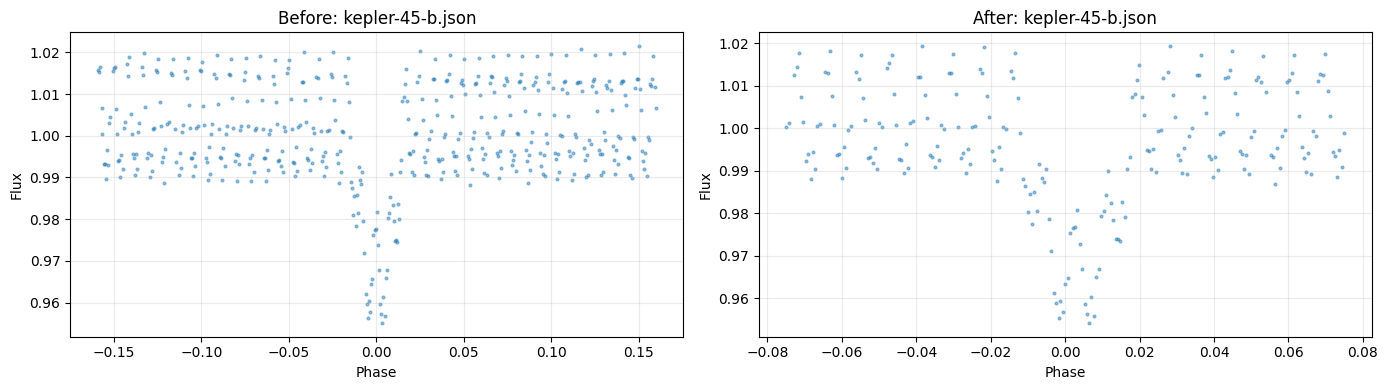

Before points: 472 phase range: (-0.1591, 0.1597)
After points: 224 phase range: (-0.0749, 0.0749)


In [14]:
sample_name = "kepler-45-b.json"

if not (BACKUP_DIR / sample_name).exists():
    existing = sorted([p.name for p in LC_DIR.glob("*.json")])
    print("Sample not found. First available files:")
    print(existing[:30])
    sample_name = existing[0] if existing else None

if sample_name:
    before_path = BACKUP_DIR / sample_name
    after_path = LC_DIR / sample_name

    p0, f0, _ = load_phase_flux(before_path)
    p1, f1, _ = load_phase_flux(after_path)

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    ax[0].scatter(p0, f0, s=4, alpha=0.45)
    ax[0].set_title(f"Before: {sample_name}")
    ax[0].set_xlabel("Phase")
    ax[0].set_ylabel("Flux")
    ax[0].grid(alpha=0.25)

    ax[1].scatter(p1, f1, s=4, alpha=0.45)
    ax[1].set_title(f"After: {sample_name}")
    ax[1].set_xlabel("Phase")
    ax[1].set_ylabel("Flux")
    ax[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    print("Before points:", len(p0), "phase range:", (round(float(p0.min()), 4), round(float(p0.max()), 4)))
    print("After points:", len(p1), "phase range:", (round(float(p1.min()), 4), round(float(p1.max()), 4)))

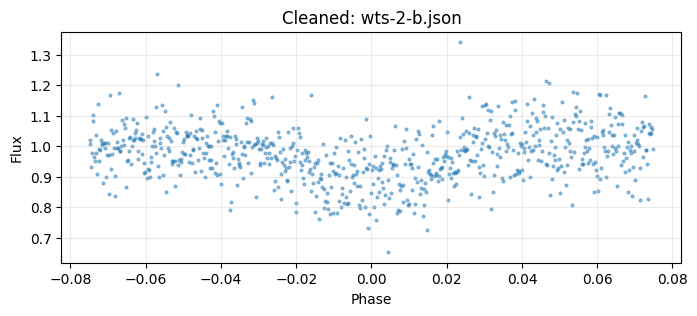

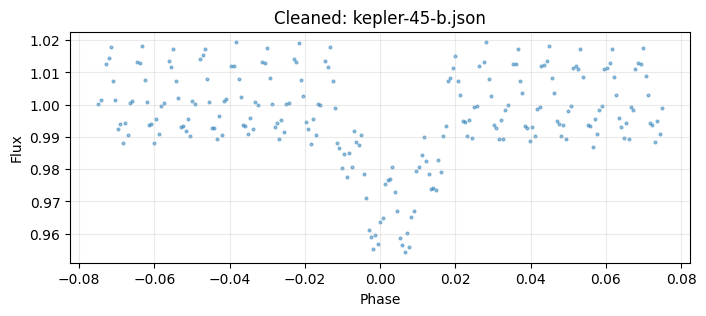

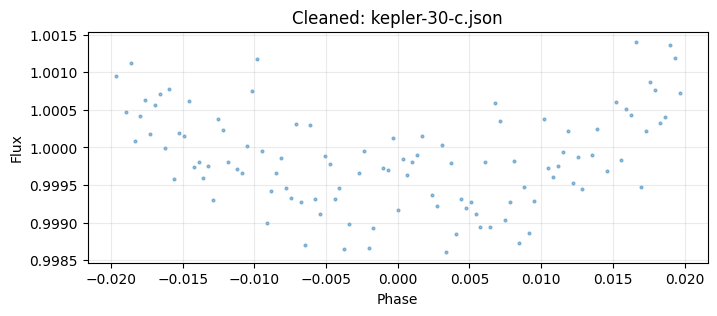

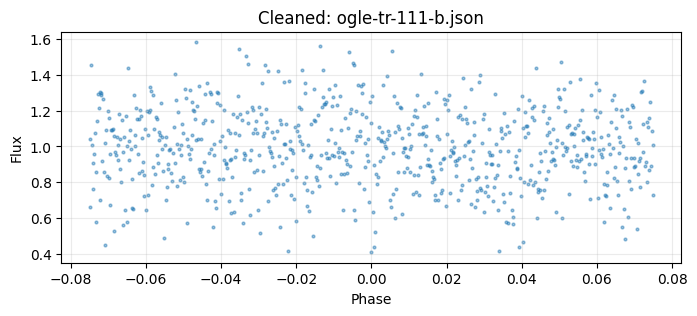

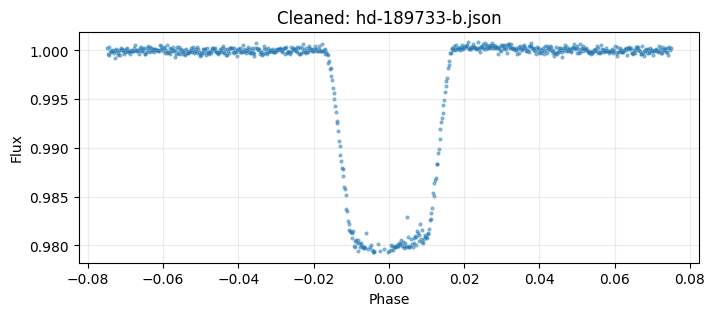

In [15]:
for sample_name in ["wts-2-b.json", "kepler-45-b.json", "kepler-30-c.json", "ogle-tr-111-b.json", "hd-189733-b.json"]:
    if (LC_DIR / sample_name).exists() and (BACKUP_DIR / sample_name).exists():
        p0, f0, _ = load_phase_flux(BACKUP_DIR / sample_name)
        p1, f1, _ = load_phase_flux(LC_DIR / sample_name)

        plt.figure(figsize=(8, 3))
        plt.scatter(p1, f1, s=4, alpha=0.45)
        plt.title(f"Cleaned: {sample_name}")
        plt.xlabel("Phase")
        plt.ylabel("Flux")
        plt.grid(alpha=0.25)
        plt.show()

In [16]:
FINAL_ZIP = Path("/content/exointel_final_200_targets_cleaned_lightcurves.zip")

if FINAL_ZIP.exists():
    FINAL_ZIP.unlink()

with zipfile.ZipFile(FINAL_ZIP, "w", zipfile.ZIP_DEFLATED) as z:
    z.write(EXOPLANET_JSON, EXOPLANET_JSON.relative_to(FINAL_DIR))

    for path in sorted(LC_DIR.glob("*.json")):
        z.write(path, path.relative_to(FINAL_DIR))

print("Created:", FINAL_ZIP)
print("Size:", round(FINAL_ZIP.stat().st_size / 1024 / 1024, 2), "MB")

with zipfile.ZipFile(FINAL_ZIP, "r") as z:
    names = z.namelist()
    print("Files in final ZIP:", len(names))
    print("First 20:")
    for n in names[:20]:
        print(" ", n)

Created: /content/exointel_final_200_targets_cleaned_lightcurves.zip
Size: 1.29 MB
Files in final ZIP: 175
First 20:
  data/exoplanets.json
  data/lightcurves/corot-11-b.json
  data/lightcurves/corot-13-b.json
  data/lightcurves/corot-18-b.json
  data/lightcurves/corot-3-b.json
  data/lightcurves/corot-8-b.json
  data/lightcurves/hat-p-1-b.json
  data/lightcurves/hat-p-13-b.json
  data/lightcurves/hat-p-18-b.json
  data/lightcurves/hat-p-2-b.json
  data/lightcurves/hat-p-22-b.json
  data/lightcurves/hat-p-27-b.json
  data/lightcurves/hat-p-37-b.json
  data/lightcurves/hat-p-39-b.json
  data/lightcurves/hat-p-41-b.json
  data/lightcurves/hat-p-42-b.json
  data/lightcurves/hat-p-45-b.json
  data/lightcurves/hat-p-53-b.json
  data/lightcurves/hats-5-b.json
  data/lightcurves/hats-6-b.json


In [17]:
from google.colab import files

files.download(str(FINAL_ZIP))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>